<a href="https://colab.research.google.com/github/sabrinanicacio/GPS-AA272/blob/main/Pablo_SiteErrorAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved mask: /content/drive/MyDrive/AA272/HW2/data/mask_GruithuisenDomes.csv
Saved mask: /content/drive/MyDrive/AA272/HW2/data/mask_MariusHills.csv
Saved mask: /content/drive/MyDrive/AA272/HW2/data/mask_RimaBode.csv
Saved mask: /content/drive/MyDrive/AA272/HW2/data/mask_Shackleton.csv

--- GruithuisenDomes skyplot ---


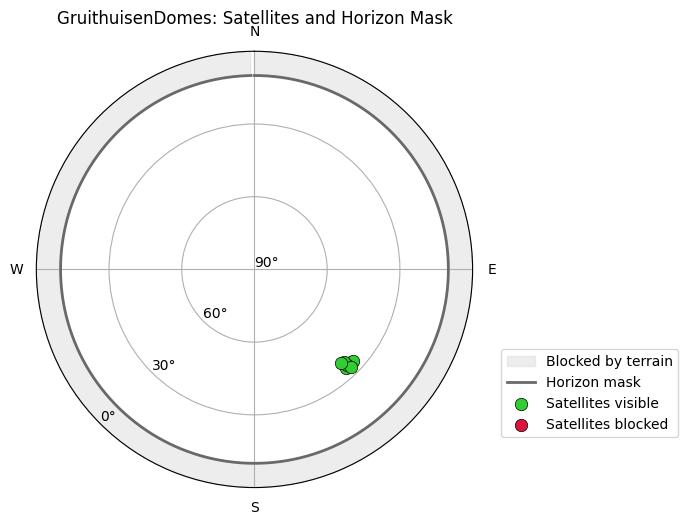


--- MariusHills skyplot ---


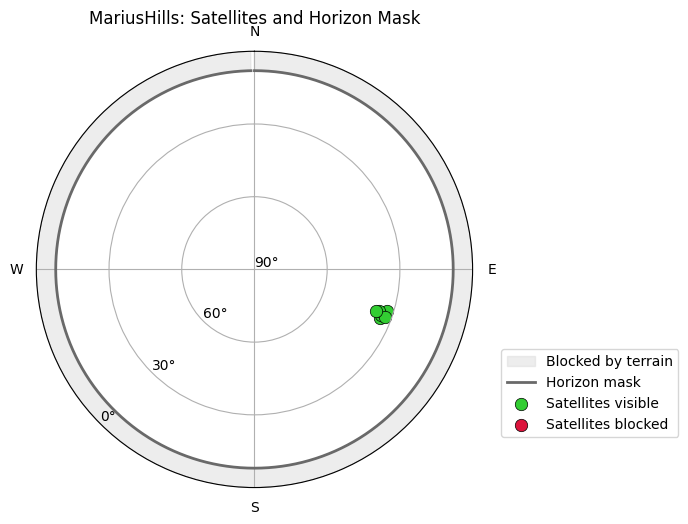


--- RimaBode skyplot ---


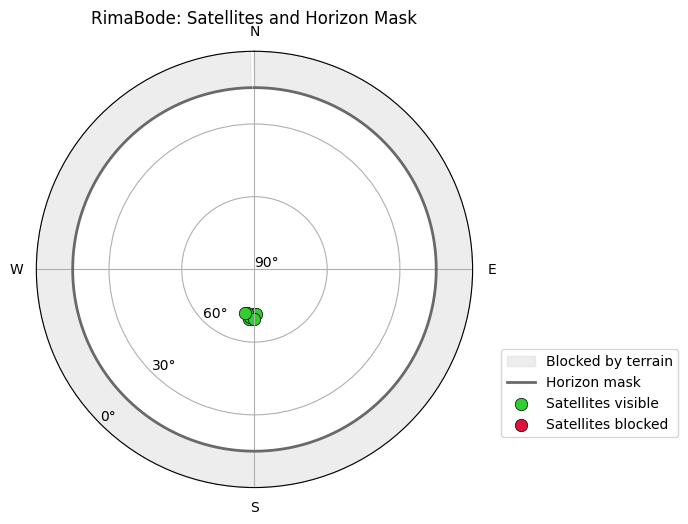


--- Shackleton skyplot ---


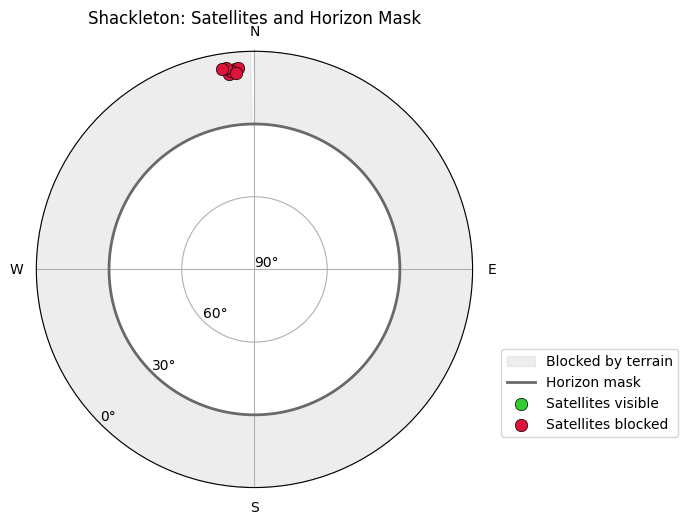


=== GruithuisenDomes DOP ===
  Satellites (open sky)   : 7
  Satellites (after mask) : 7
  PDOP open sky           : 1364.55


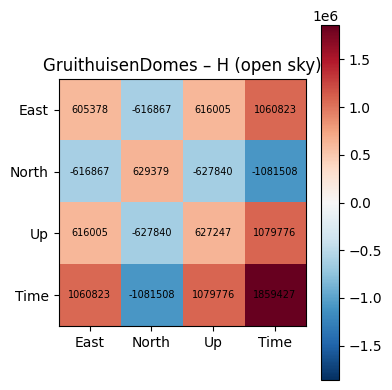

  PDOP with mask          : 1364.55


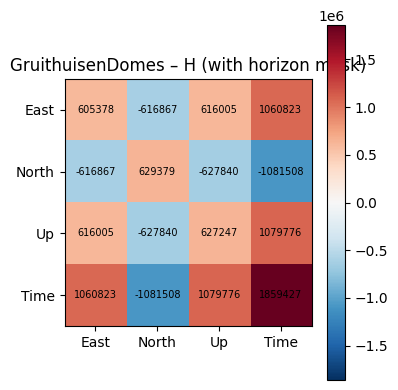


=== MariusHills DOP ===
  Satellites (open sky)   : 7
  Satellites (after mask) : 7
  PDOP open sky           : 1364.81


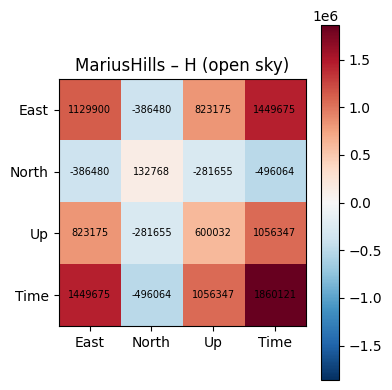

  PDOP with mask          : 1364.81


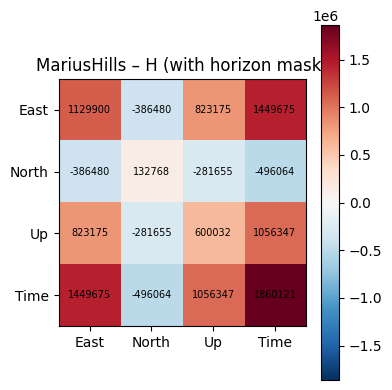


=== RimaBode DOP ===
  Satellites (open sky)   : 7
  Satellites (after mask) : 7
  PDOP open sky           : 1359.58


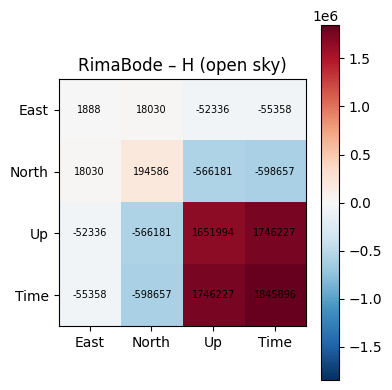

  PDOP with mask          : 1359.58


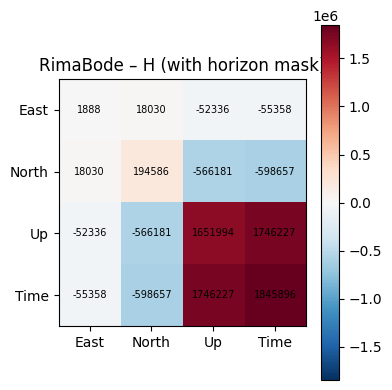


=== Shackleton DOP ===
  Satellites (open sky)   : 7
  Satellites (after mask) : 0
  PDOP open sky           : 1372.15


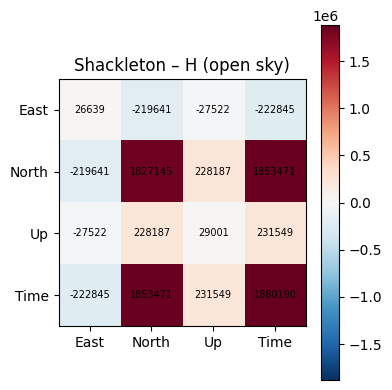

  Not enough visible satellites after mask to compute DOP.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# 0. Paths and simple mask generation

BASE = "/content/drive/MyDrive/AA272/HW2/data"

# Satellite az/el CSVs from your HW (matching your Drive)
sat_files = {
    "GruithuisenDomes" : f"{BASE}/hw2_p3_bonus_GruithuisenDomes.csv",
    "MariusHills"      : f"{BASE}/hw2_p3_bonus_MariusHills.csv",
    "RimaBode"         : f"{BASE}/hw2_p3_bonus_RimaBode.csv",
    "Shackleton"       : f"{BASE}/hw2_p3_bonus_Shackleton.csv",
}

# Simple constant masks (deg) – good for testing
mask_levels = {
    "GruithuisenDomes" : 10,
    "MariusHills"      : 8,
    "RimaBode"         : 15,
    "Shackleton"       : 30,
}

# Create mask CSVs (safe to rerun)
def make_mask(filename, elev_value):
    az = np.arange(360)
    elev = np.full(360, elev_value)
    df = pd.DataFrame({"az_deg": az, "elev_mask_deg": elev})
    df.to_csv(filename, index=False)
    print("Saved mask:", filename)

mask_files = {}
for loc, level in mask_levels.items():
    fname = f"{BASE}/mask_{loc}.csv"
    make_mask(fname, level)
    mask_files[loc] = fname

# 1. DOP utilities

def get_unit_vector(az_deg, el_deg):
    az = np.deg2rad(az_deg)
    el = np.deg2rad(el_deg)
    uE = np.cos(el) * np.sin(az)
    uN = np.cos(el) * np.cos(az)
    uU = np.sin(el)
    u  = np.array([uE, uN, uU], dtype=float)
    n  = np.linalg.norm(u)
    return u / n if n > 0 else u

def compute_dop_matrix(az_arr, el_arr):
    az_arr = np.asarray(az_arr, float).ravel()
    el_arr = np.asarray(el_arr, float).ravel()
    if az_arr.size < 4:
        raise ValueError("Need at least 4 satellites to compute DOP.")
    rows = []
    for az, el in zip(az_arr, el_arr):
        uE, uN, uU = get_unit_vector(az, el)
        rows.append([-uE, -uN, -uU, 1.0])
    G = np.asarray(rows)
    H = np.linalg.inv(G.T @ G)
    return H, G

def compute_pdop(H):
    return float(np.sqrt(H[0,0] + H[1,1] + H[2,2]))

def compute_hdop(H):
    return float(np.sqrt(H[0,0] + H[1,1]))

def compute_vdop(H):
    return float(np.sqrt(H[2,2]))

def compute_tdop(H):
    return float(np.sqrt(H[3,3]))

def plot_dop_matrix(H, title=""):
    plt.figure(figsize=(4,4))
    vmax = max(20, np.max(np.abs(H)))   # symmetric, but clip for visibility
    plt.imshow(H, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    plt.colorbar()
    labels = ["East", "North", "Up", "Time"]
    plt.xticks(range(4), labels)
    plt.yticks(range(4), labels)
    for (i, j), val in np.ndenumerate(H):
        plt.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)
    plt.title(title)
    plt.tight_layout()

# 2. Load satellite and mask data

def load_sat_data(path):
    df = pd.read_csv(path)
    az = df["az_sv_deg"].values
    el = df["el_sv_deg"].values
    return az, el

def load_mask(path):
    dfm = pd.read_csv(path)
    az_mask = dfm["az_deg"].values.astype(float)
    elev_mask = dfm["elev_mask_deg"].values.astype(float)
    idx = np.argsort(az_mask)
    return az_mask[idx], elev_mask[idx]


# 3. Horizon mask visibility

def visible_with_mask(az_sat_deg, el_sat_deg, az_mask_deg, elev_mask_deg):
    az = az_sat_deg % 360.0
    elev_req = np.interp(az, az_mask_deg, elev_mask_deg)
    return el_sat_deg > elev_req, elev_req

def compute_masked_geometry(az_sat, el_sat, az_mask, elev_mask):
    az_vis, el_vis = [], []
    for a, e in zip(az_sat, el_sat):
        vis, _ = visible_with_mask(a, e, az_mask, elev_mask)
        if vis:
            az_vis.append(a)
            el_vis.append(e)
    return np.array(az_vis), np.array(el_vis)

# 4. Skyplot with horizon mask + visible/blocked sats

def plot_sky_with_mask(location_name, sat_path, mask_path):
    az_sat, el_sat = load_sat_data(sat_path)
    az_mask, elev_mask = load_mask(mask_path)

    # classify sats
    visible_flags = []
    for a, e in zip(az_sat, el_sat):
        vis, _ = visible_with_mask(a, e, az_mask, elev_mask)
        visible_flags.append(vis)
    visible_flags = np.array(visible_flags, dtype=bool)

    # polar coords
    theta_sat = np.deg2rad(az_sat)
    r_sat     = 90.0 - el_sat

    theta_mask = np.deg2rad(az_mask)
    r_mask     = 90.0 - elev_mask

    plt.figure(figsize=(7,7))
    ax = plt.subplot(111, polar=True)

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    # full sky: 0–90 deg elevation
    ax.set_rlim(0, 90)
    ax.set_rticks([90, 60, 30, 0])
    ax.set_yticklabels(["0°", "30°", "60°", "90°"])
    ax.set_rlabel_position(225)
    ax.set_thetagrids([0, 90, 180, 270], labels=["N","E","S","W"])

    # blocked region from rim to horizon
    theta_poly = np.concatenate([theta_mask, theta_mask[::-1]])
    r_poly = np.concatenate([r_mask, np.full_like(r_mask, 90.0)])
    ax.fill(theta_poly, r_poly, color="lightgray", alpha=0.4, label="Blocked by terrain")

    # mask curve
    ax.plot(theta_mask, r_mask, color="dimgray", linewidth=2, label="Horizon mask")

    # satellites
    ax.scatter(theta_sat[visible_flags],
               r_sat[visible_flags],
               s=80, c="limegreen", edgecolors="k", linewidths=0.5,
               label="Satellites visible")
    ax.scatter(theta_sat[~visible_flags],
               r_sat[~visible_flags],
               s=80, c="crimson", edgecolors="k", linewidths=0.5,
               label="Satellites blocked")

    ax.set_title(f"{location_name}: Satellites and Horizon Mask", pad=20)
    ax.legend(loc="lower left", bbox_to_anchor=(1.05, 0.1))
    plt.tight_layout()
    plt.show()

# 5. Run: skyplots + H matrices for all craters

# 5a. Skyplots
for loc in sat_files.keys():
    print(f"\n--- {loc} skyplot ---")
    plot_sky_with_mask(loc, sat_files[loc], mask_files[loc])

# 5b. H matrices and PDOP with/without mask
for loc in sat_files.keys():
    print(f"\n=== {loc} DOP ===")

    az_sat, el_sat = load_sat_data(sat_files[loc])
    az_mask, elev_mask = load_mask(mask_files[loc])

    # open-sky geometry
    H_open, _ = compute_dop_matrix(az_sat, el_sat)
    pdop_open = compute_pdop(H_open)

    # masked geometry
    az_vis, el_vis = compute_masked_geometry(az_sat, el_sat, az_mask, elev_mask)
    n_open = len(az_sat)
    n_vis  = len(az_vis)

    print(f"  Satellites (open sky)   : {n_open}")
    print(f"  Satellites (after mask) : {n_vis}")
    print(f"  PDOP open sky           : {pdop_open:.2f}")

    plot_dop_matrix(H_open, title=f"{loc} – H (open sky)")
    plt.show()

    if n_vis >= 4:
        H_mask, _ = compute_dop_matrix(az_vis, el_vis)
        pdop_mask = compute_pdop(H_mask)
        print(f"  PDOP with mask          : {pdop_mask:.2f}")
        plot_dop_matrix(H_mask, title=f"{loc} – H (with horizon mask)")
        plt.show()
    else:
        print("  Not enough visible satellites after mask to compute DOP.")



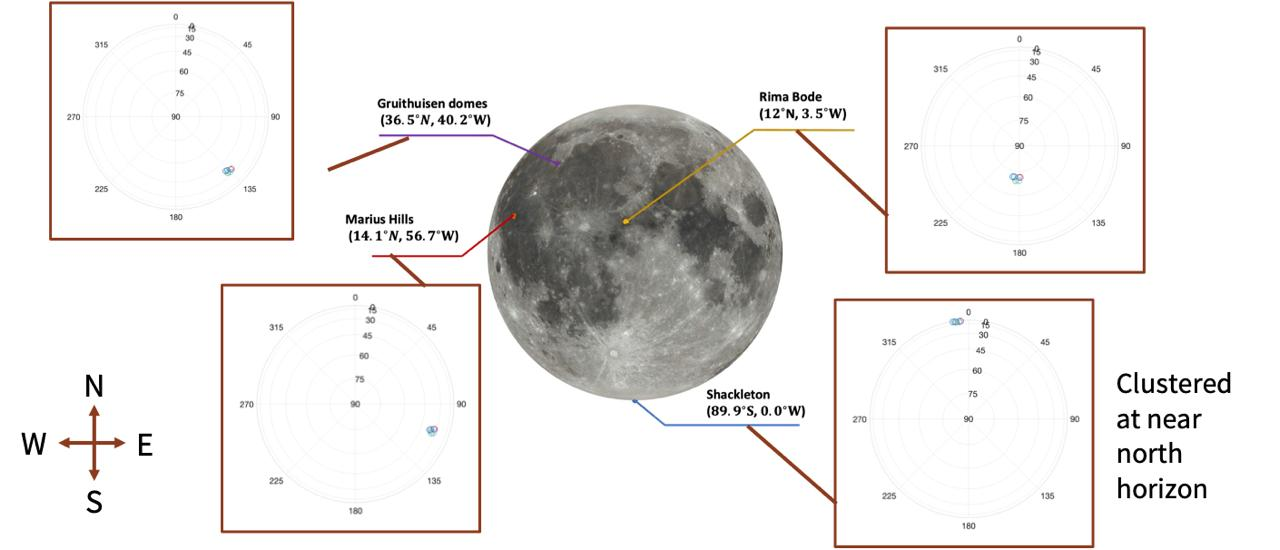